# Parallel Agents with Fan-Out / Fan-In

When an agent needs to perform N independent subtasks, running them one after another takes **O(N)** wall-clock time. LangGraph's **`Send` API** lets you fan out to N parallel workers in a single graph step, bringing wall-clock time down to roughly **O(1)**.

This notebook covers:
1. The `Send` API — dynamic fan-out from a conditional edge
2. The `operator.add` reducer — collecting results from parallel branches
3. Fan-in aggregation — a downstream node that fires only after all branches complete
4. A timing comparison — sequential vs. parallel web searches

This is the only notebook in the course that uses `Send`. All other multi-step patterns (e.g. the deep research agent) loop sequentially.

> **Note:** Graph logic lives in [`parallel_graphs.py`](parallel_graphs.py) to work around a quirk: LangGraph runs `Send` nodes in a thread pool, and the SerpAPI client corrupts Jupyter's stdout from threads.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)
# Expects: OPENROUTER_API_KEY, SERPAPI_API_KEY
# Optional: LANGSMITH_API_KEY

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-4.1-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0.3,
)

## The `Send` API

Normally, LangGraph edges are defined at build time. `Send` lets a **conditional edge** dynamically dispatch N invocations of the same node, each with its own payload:

```python
from langgraph.types import Send

def route_tasks(state):
    return [Send("worker", {"task": t}) for t in state["tasks"]]
```

All dispatched nodes run **in parallel** within the same graph step. Results are merged back into the shared state via a **reducer** (e.g. `Annotated[list, operator.add]`). The next downstream node only fires after every `Send` branch completes — an implicit barrier.

> **How parallelism works:** LangGraph runs sync `Send` nodes in a **thread pool**, so even blocking calls like `time.sleep` or `requests.get` execute truly in parallel (up to `max_concurrency`, default 20). No async/await needed.

## Graph code walkthrough

The full graph is defined in [`parallel_graphs.py`](parallel_graphs.py). Here's the key structure:

```python
class ParallelState(TypedDict):
    topic: str
    tasks: list[str]
    results: Annotated[list[str], operator.add]  # reducer collects parallel outputs
    summary: str

# coordinator_node  — LLM decomposes topic into 4 search queries
# worker_node       — runs a single SerpAPI search
# aggregator_node   — LLM synthesizes all search results

graph.add_edge(START, "coordinator")
graph.add_conditional_edges("coordinator", route_tasks, ["worker"])  # fan-out
graph.add_edge("worker", "aggregator")                              # fan-in
graph.add_edge("aggregator", END)
```

In [3]:
from parallel_graphs import build_graphs, safe_invoke

app, search_app = build_graphs(llm)

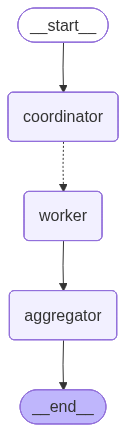

In [4]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
result = safe_invoke(app, {"topic": "The impact of AI on healthcare"})

print("Coordinator tasks:")
for i, t in enumerate(result["tasks"], 1):
    print(f"  {i}. {t}")

print(f"\n{'='*60}")
print(f"Final summary:\n{result['summary']}")

Coordinator tasks:
  1. AI applications in healthcare diagnosis
  2. Benefits of AI in patient treatment and care
  3. Challenges and ethical issues of AI in healthcare
  4. Future trends of AI technology in healthcare

Final summary:
AI is significantly transforming healthcare by enhancing diagnostic accuracy, accelerating decision-making, and personalizing patient treatment and care. It supports clinicians through advanced data analysis, medical imaging interpretation, and predictive analytics, ultimately improving patient outcomes and healthcare system efficiency. However, challenges such as ethical concerns, data privacy, algorithmic bias, and changes in healthcare roles must be carefully managed. Looking ahead, AI is poised to further revolutionize medicine with innovations in remote monitoring, clinical trials, and drug discovery, empowering healthcare providers and patients alike.


## Sequential vs. Parallel

Without `Send`, you would loop through each task one at a time. To make a fair comparison, we run the **same 4 SerpAPI searches** both ways — once sequentially in a `for` loop, and once in parallel via a Send-based graph. No LLM calls in either path, so the only variable is sequential vs. parallel I/O.

In [6]:
import time
from parallel_graphs import serp_search

tasks = result["tasks"]

# -- Parallel: Send-based graph (search only, no LLM) ---------------------

start = time.time()
safe_invoke(search_app, {"topic": "", "tasks": tasks})
parallel_time = time.time() - start

# -- Sequential: plain for-loop -------------------------------------------

start = time.time()
for t in tasks:
    safe_invoke(search_app, {"topic": "", "tasks": [t]})
sequential_time = time.time() - start

# -- Results ---------------------------------------------------------------

print(f"Parallel:   {parallel_time:.1f}s")
print(f"Sequential: {sequential_time:.1f}s")
print(f"Speedup:    {sequential_time / parallel_time:.1f}x")

Parallel:   0.1s
Sequential: 0.3s
Speedup:    2.9x


## Takeaways

- **`Send` enables dynamic fan-out** — the number of parallel branches is determined at runtime, not at graph build time
- **`operator.add` reducer** collects results from all parallel branches into a single list
- **Implicit barrier** — the aggregator node only fires after every `Send` branch completes
- **Thread-pool parallelism** — sync nodes dispatched via `Send` run in parallel threads, so blocking I/O (`time.sleep`, `requests.get`, etc.) is truly concurrent
- **Scales to any N** — the same code works for 2 workers or 200; just return more `Send` objects from the conditional edge